In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

if os.path.exists("data"):
    DATA_DIR = "data"
elif os.path.exists("../data"):
    DATA_DIR = "../data"

print(f"✅ Папка данных: {DATA_DIR}")

✅ Папка данных: ../data


In [2]:
df_synth = pd.read_csv(f"{DATA_DIR}/synthetic_data.csv")

print("📊 Диагностика синтетики:")
print(f"   Размер: {df_synth.shape}")
print(f"   Доля дефолтов: {df_synth['default'].mean():.1%}")
print(f"   Средний доход: {df_synth['income'].mean():.0f}")
print(f"   Средний расход: {df_synth['expense'].mean():.0f}")

feature_cols = ['income', 'expense', 'debt_ratio', 'balance', 
                'active_cards', 'days_on_platform', 'closed_credits', 'has_overdue']

X_synth = df_synth[feature_cols]
y_synth = df_synth['default']

scaler = StandardScaler()
X_synth_scaled = scaler.fit_transform(X_synth)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_synth_scaled, y_synth)

print("\n✅ ML-модель обучена на синтетике")
print(f"Кол-во признаков: {len(feature_cols)}")

📊 Диагностика синтетики:
   Размер: (1000, 9)
   Доля дефолтов: 23.3%
   Средний доход: 22181
   Средний расход: 8345

✅ ML-модель обучена на синтетике
Кол-во признаков: 8


In [3]:
df_real = pd.read_csv(f"{DATA_DIR}/features_with_target.csv")
print(f"Реальных пользователей: {len(df_real)}")
df_real[['userId', 'income', 'expense', 'debt_ratio', 'balance', 'has_overdue']]

Реальных пользователей: 10


,userId,income,expense,debt_ratio,balance,has_overdue
0,9,35000.000000,17066.666667,0.487619,178550.000000,0
1,10,20000.000000,2766.666667,0.138333,225400.000000,0
2,1,21666.666667,8832.817011,0.407668,145140.548968,0
3,2,21666.666667,6333.333333,0.292308,175300.000000,0
4,3,35000.000000,12333.333333,0.352381,146650.000000,0
5,4,15000.000000,2150.000000,0.143333,210250.000000,0
6,5,40000.000000,16000.000000,0.400000,183800.000000,0
7,6,18333.333333,2300.000000,0.125455,177000.000000,0
8,7,30000.000000,5066.666667,0.168889,229742.100000,0
9,8,16666.666667,3616.666667,0.217000,135050.000000,0


In [4]:
WEIGHTS = {
    'income': 1.5, 'expense': 0.8, 'debt_ratio': 1.2, 'balance': 1.0,
    'active_cards': 0.5, 'days_on_platform': 0.7, 'closed_credits': 1.0, 'has_overdue': 1.3,
}
INFLUENCE = {
    'income': '+', 'expense': '-', 'debt_ratio': '-', 'balance': '+',
    'active_cards': '+', 'days_on_platform': '+', 'closed_credits': '+', 'has_overdue': '-',
}

max_values = {col: df_real[col].max() for col in WEIGHTS.keys()}

def additive_score(row):
    score = 0
    for col, weight in WEIGHTS.items():
        value = row[col]
        max_val = max_values[col]
        if max_val == 0:
            norm = 0
        elif INFLUENCE[col] == '+':
            norm = min(value / max_val, 1.0)
        else:
            norm = 1 - min(value / max_val, 1.0)
        score += weight * norm
    return score

def additive_rate(score):
    MAX_SCORE = 8.0
    return round(5 + (1 - score / MAX_SCORE) * 20, 2)

df_real['additive_score'] = df_real.apply(additive_score, axis=1)
df_real['additive_rate'] = df_real['additive_score'].apply(additive_rate)

print("✅ Аддитивная свёртка посчитана")
df_real[['userId', 'additive_score', 'additive_rate']]

✅ Аддитивная свёртка посчитана


,userId,additive_score,additive_rate
0,9,2.709676,18.23
1,10,3.751116,15.62
2,1,4.226969,14.43
3,2,3.403304,16.49
4,3,3.643512,15.89
5,4,3.674808,15.81
6,5,3.197653,17.01
7,6,3.645381,15.89
8,7,4.397875,14.01
9,8,3.057278,17.36


In [5]:
X_real = df_real[feature_cols]
X_real_scaled = scaler.transform(X_real)

df_real['ml_default_proba'] = model.predict_proba(X_real_scaled)[:, 1]
df_real['ml_rate'] = round(5 + df_real['ml_default_proba'] * 20, 2)

print("✅ ML-ставка посчитана")
df_real[['userId', 'ml_default_proba', 'ml_rate']]

✅ ML-ставка посчитана


,userId,ml_default_proba,ml_rate
0,9,0.246362,9.93
1,10,0.081801,6.64
2,1,0.144315,7.89
3,2,0.150637,8.01
4,3,0.165489,8.31
5,4,0.094594,6.89
6,5,0.197773,8.96
7,6,0.089416,6.79
8,7,0.078031,6.56
9,8,0.117462,7.35


In [6]:
comparison = df_real[[
    'userId', 'income', 'expense', 'debt_ratio',
    'additive_score', 'additive_rate', 
    'ml_default_proba', 'ml_rate'
]].copy()

comparison['difference'] = comparison['ml_rate'] - comparison['additive_rate']

print("🏆 Сравнение аддитивной свёртки и ML-модели:")
comparison.round(2)

🏆 Сравнение аддитивной свёртки и ML-модели:


,userId,income,expense,debt_ratio,additive_score,additive_rate,ml_default_proba,ml_rate,difference
0,9,35000.00,17066.67,0.49,2.71,18.23,0.25,9.93,-8.30
1,10,20000.00,2766.67,0.14,3.75,15.62,0.08,6.64,-8.98
2,1,21666.67,8832.82,0.41,4.23,14.43,0.14,7.89,-6.54
3,2,21666.67,6333.33,0.29,3.40,16.49,0.15,8.01,-8.48
4,3,35000.00,12333.33,0.35,3.64,15.89,0.17,8.31,-7.58
5,4,15000.00,2150.00,0.14,3.67,15.81,0.09,6.89,-8.92
6,5,40000.00,16000.00,0.40,3.20,17.01,0.20,8.96,-8.05
7,6,18333.33,2300.00,0.13,3.65,15.89,0.09,6.79,-9.10
8,7,30000.00,5066.67,0.17,4.40,14.01,0.08,6.56,-7.45
9,8,16666.67,3616.67,0.22,3.06,17.36,0.12,7.35,-10.01


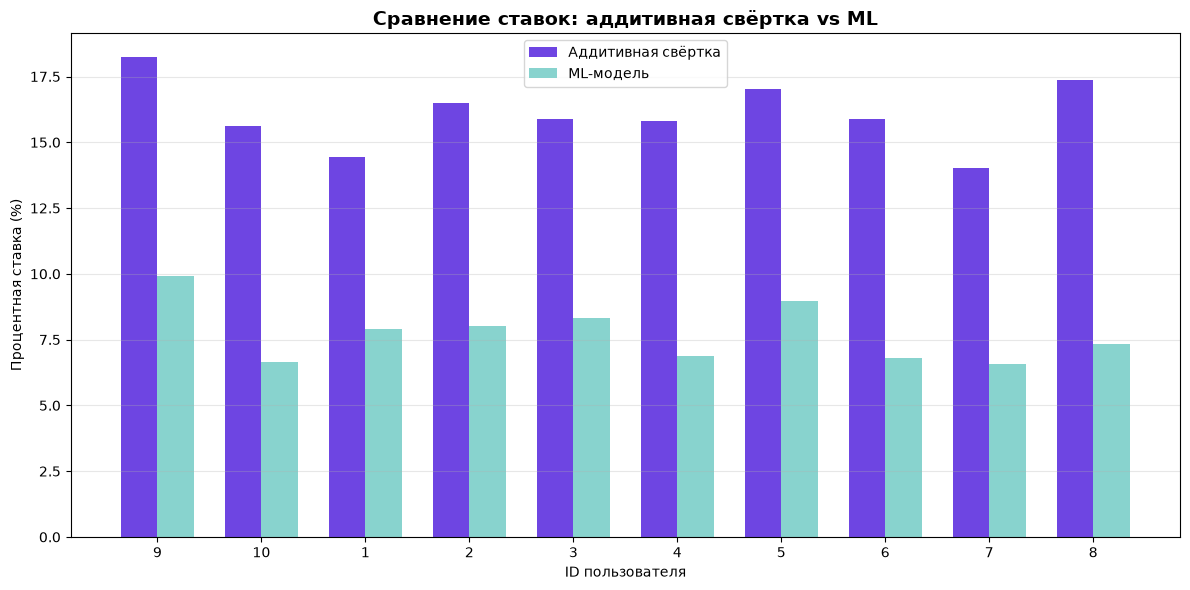

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison['additive_rate'], width, label='Аддитивная свёртка', color='#6e45e2')
ax.bar(x + width/2, comparison['ml_rate'], width, label='ML-модель', color='#88d3ce')

ax.set_xticks(x)
ax.set_xticklabels(comparison['userId'].astype(str))
ax.set_xlabel('ID пользователя')
ax.set_ylabel('Процентная ставка (%)')
ax.set_title('Сравнение ставок: аддитивная свёртка vs ML', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()